Implementation of Gaussaian Mixture Model using EM Algorithm.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
x=pd.read_csv('/content/drive/MyDrive/Data set/GMM_Dataset.csv')
print(x)
x=np.array(x)
X=x.reshape(-1,1)
mean=np.array([1,2])
theta=np.array([0.33,0.67])

           x
0    0.29617
1    1.20080
2    1.09020
3   -0.35870
4   -0.12993
..       ...
995  2.31570
996  2.90200
997  3.03920
998  1.76640
999  2.23160

[1000 rows x 1 columns]


In [ ]:
P=np.zeros((len(X),2))
def likelihood(X,mean,theta):
  like=np.sum(theta*np.exp(-(X-mean)**2/2)/np.sqrt(2*np.pi),axis=1)
  loglike=np.sum(np.log(like))
  return loglike
loglike=likelihood(X,mean,theta)
print(loglike)

-2136.1561523392647


In [ ]:
def expectation(X,mean,theta):
  pdf=theta*(np.exp(-(X-mean)**2/2)/np.sqrt(2*np.pi))
  P=pdf/np.sum(pdf,axis=1,keepdims=True)
  return P
P=expectation(X,mean,theta)
print(P)

[[0.62143533 0.37856467]
 [0.39915551 0.60084449]
 [0.42595232 0.57404768]
 ...
 [0.09557526 0.90442474]
 [0.27396755 0.72603245]
 [0.19157864 0.80842136]]


In [ ]:
def maximisation(X,P):
  mean=np.sum(P*X,axis=0)/np.sum(P,axis=0)
  theta=np.sum(P,axis=0)/len(X)
  return mean,theta
mean,theta=maximisation(X,P)
print(mean,theta)


[0.21076412 2.07160849] [0.42095579 0.57904421]


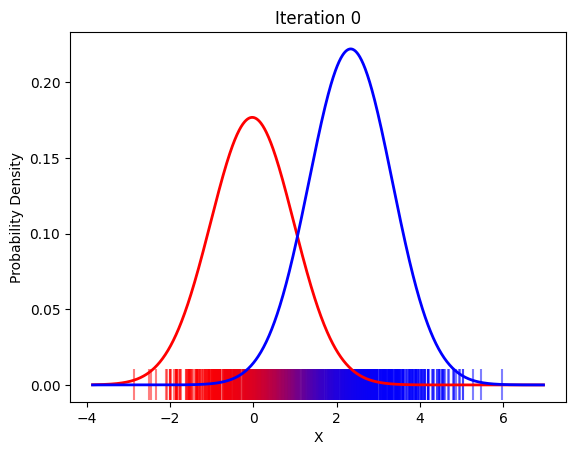

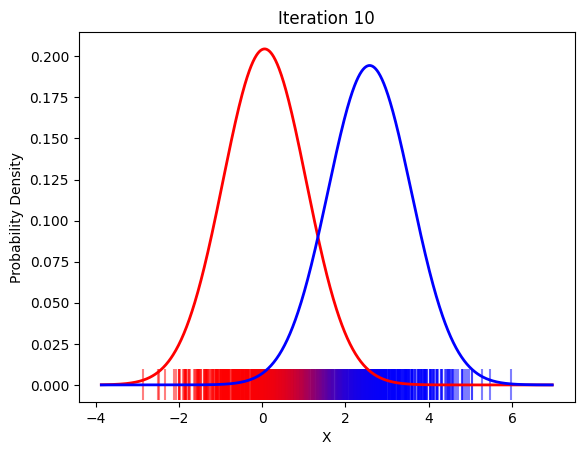

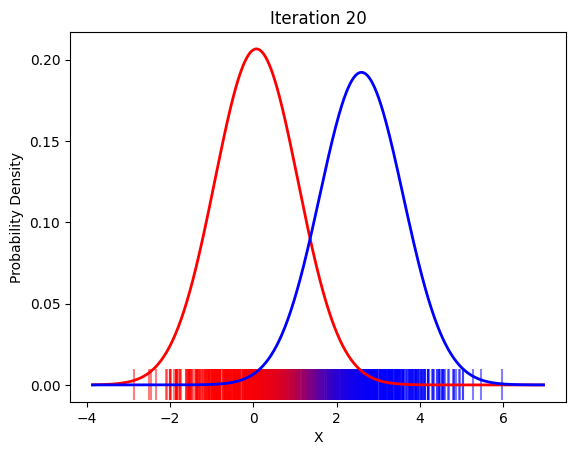

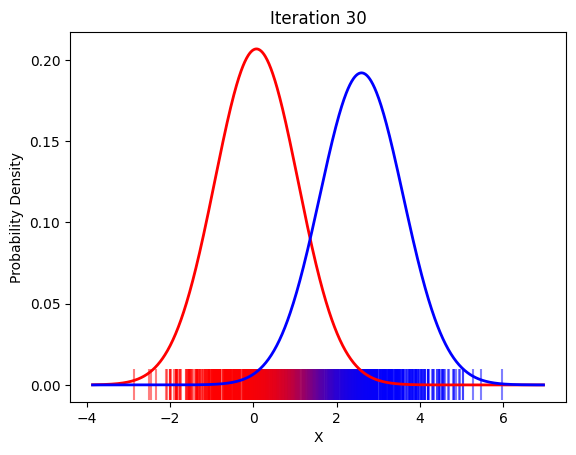

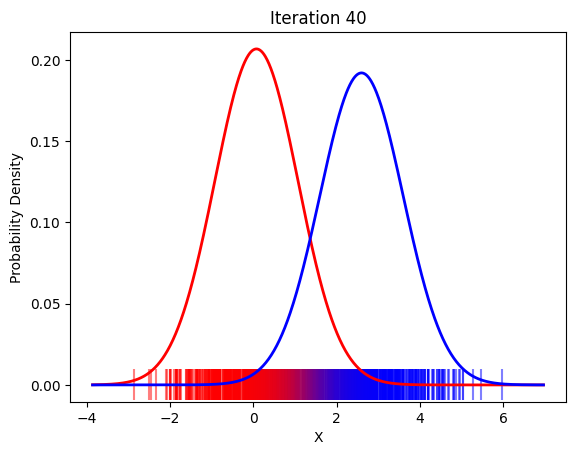

40
[0.07348424 2.5964232 ]
[0.51850162 0.48149838]
-1869.1085058000967


In [ ]:
for i in range(1000):
  new_loglike=likelihood(X,mean,theta)
  P=expectation(X,mean,theta)
  mean,theta=maximisation(X,P)

  if i%10==0:
    x_axis = np.linspace(np.min(X) - 1, np.max(X) + 1, 1000).reshape(-1, 1)
    c1 = theta[0] * np.exp(-(x_axis - mean[0])**2 / 2) / np.sqrt(2 * np.pi)
    c2 = theta[1] * np.exp(-(x_axis - mean[1])**2 / 2) / np.sqrt(2 * np.pi)
    colors = np.zeros((len(X), 4))
    colors[:, 0] = P[:, 0]
    colors[:, 2] = P[:, 1]
    colors[:, 3] = 0.5
    plt.figure()
    plt.plot(x_axis, c1, color='red', linewidth=2)
    plt.plot(x_axis, c2, color='blue', linewidth=2)
    plt.scatter(X, np.zeros_like(X), c=colors, marker='|', s=500)
    plt.title(f"Iteration {i}")
    plt.xlabel("X")
    plt.ylabel("Probability Density")
    plt.show()
  if np.abs(new_loglike-loglike)<1e-8:
    print(i)
    break
  loglike = new_loglike
print(mean)
print(theta)
print(loglike)

Text(0, 0.5, 'Probability Density')

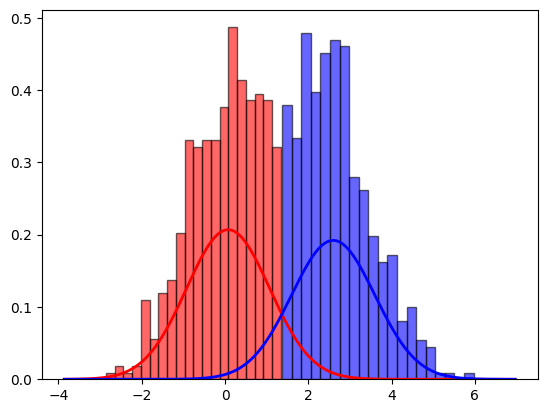

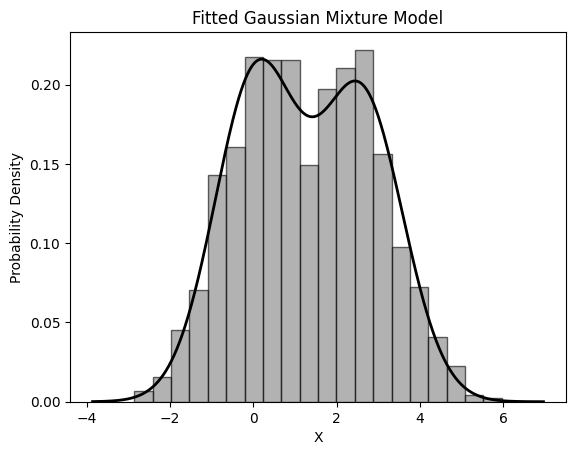

In [ ]:
x_axis = np.linspace(np.min(X) - 1, np.max(X) + 1, 1000).reshape(-1,1)
curve1 = theta[0] * np.exp(-(x_axis - mean[0])**2 / 2) / np.sqrt(2 * np.pi)
curve2 = theta[1] * np.exp(-(x_axis - mean[1])**2 / 2) / np.sqrt(2 * np.pi)
colors = np.zeros((len(X), 4))
colors[:, 0] = P[:, 0]
colors[:, 2] = P[:, 1]
colors[:, 3] = 0.5
combinedcurve = curve1 + curve2
plt.figure()
hard=np.argmax(P,axis=1)
X_1=X[hard==0]
X_2=X[hard==1]
plt.hist(X_1, bins=20, density=True, alpha=0.6, color='red', edgecolor='black', label='Cluster 1')
plt.hist(X_2, bins=20, density=True, alpha=0.6, color='blue', edgecolor='black', label='Cluster 2')
plt.plot(x_axis,curve1,color='red',linewidth=2,label='Cluster 1')
plt.plot(x_axis,curve2,color='blue',linewidth=2,label='Cluster 2')

plt.figure()
plt.hist(X, bins=20, density=True, alpha=0.6, color='grey', edgecolor='black', label='Original Data')
plt.plot(x_axis,combinedcurve,color='black',linewidth=2,label='GMM')
plt.title('Fitted Gaussian Mixture Model')
plt.xlabel('X')
plt.ylabel('Probability Density')